In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.mixture import GaussianMixture

In [2]:
df = pd.read_csv('GGXY.csv')
df = df[(df['Launch Angle'] != '-') & (df['Face to Path'] != '-') & (df['Carry'] != '-')]
df['Launch Angle'] = df['Launch Angle'].astype(float)
df['Face to Path'] = df['Face to Path'].astype(float)
df['Carry'] = df['Carry'].astype(float)
df = df.dropna(subset=['Launch Angle', 'Face to Path', 'Carry'])

In [3]:
X = df[['Launch Angle', 'Face to Path']]
gmm_contact = GaussianMixture(n_components=3, covariance_type='diag', random_state=42)
df['Contact Cluster'] = gmm_contact.fit_predict(X)


cluster_means = df.groupby('Contact Cluster')['Launch Angle'].mean().sort_values()


label_map = {cluster_means.index[0]: 'Fat', cluster_means.index[1]: 'Square', cluster_means.index[2]: 'Thin'}
df['Contact Type'] = df['Contact Cluster'].map(label_map)

In [4]:
def shot_direction(face_to_path):
    if face_to_path < -1:
        return 'Right'
    elif face_to_path > 2:
        return 'Left'
    else:
        return 'Straight'

In [5]:
df['Direction'] = df['Face to Path'].apply(shot_direction)

color_map = {
    ('Thin', 'Right'): '#08306B',
    ('Thin', 'Straight'): '#4292C6',
    ('Thin', 'Left'): '#DEEBF7',
    
    ('Square', 'Right'): '#3E6B0F',
    ('Square', 'Straight'): '#66C24D',
    ('Square', 'Left'): '#CFEBC2',
    
    ('Fat', 'Right'): '#67000D',
    ('Fat', 'Straight'): '#FB6A4A',
    ('Fat', 'Left'): '#FEE0D2'
}
df['Color'] = df.apply(lambda row: color_map[(row['Contact Type'], row['Direction'])], axis=1)


marker_map = {
    'Thin': '^',   
    'Square': 's', 
    'Fat': 'v'      
}

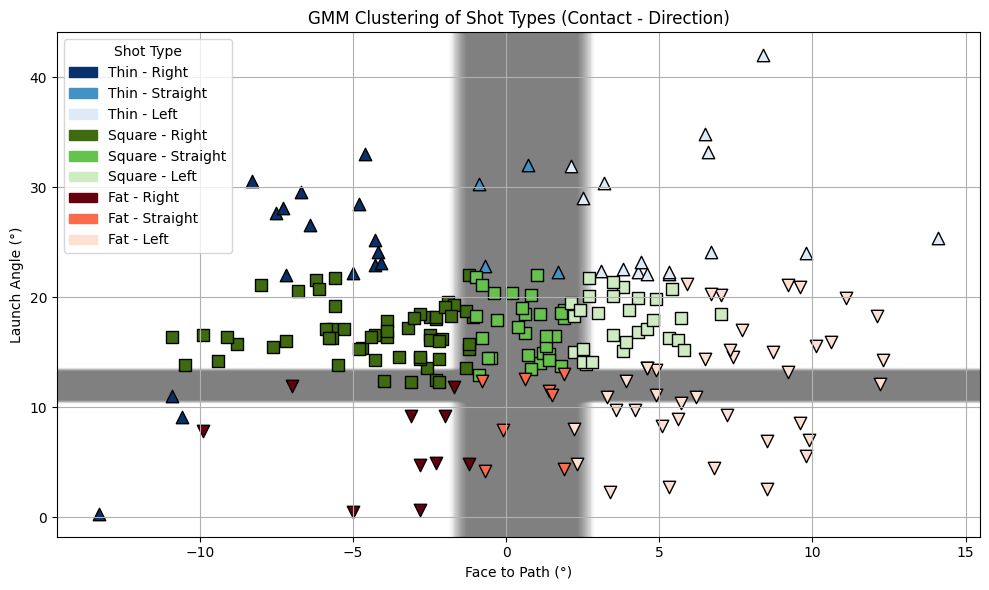

In [6]:
plt.figure(figsize=(10, 6))
for (contact, direction), color in color_map.items():
    marker = marker_map[contact]
    subset = df[(df['Contact Type'] == contact) & (df['Direction'] == direction)]
    plt.scatter(subset['Face to Path'], subset['Launch Angle'],
                color=color, edgecolor='k', s=80, marker=marker,
                label=f'{contact} - {direction}')

legend_patches = [Patch(color=color_map[key], label=f'{key[0]} - {key[1]}') for key in color_map]
plt.legend(handles=legend_patches, title='Shot Type')

ftp_center = (-1, 2)
la_center = (11, 13)
ftp_margin = (ftp_center[1] - ftp_center[0]) * 0.3
la_margin = (la_center[1] - la_center[0]) * 0.3
n_fades = 30
alphas = np.linspace(0.3, 0, n_fades)

ax = plt.gca()
for i in range(n_fades):
    x0 = ftp_center[0] - ftp_margin * (i + 1) / n_fades
    x1 = ftp_center[1] + ftp_margin * (i + 1) / n_fades
    ax.axvspan(x0, x1, color='gray', alpha=alphas[i], zorder=0)

for i in range(n_fades):
    y0 = la_center[0] - la_margin * (i + 1) / n_fades
    y1 = la_center[1] + la_margin * (i + 1) / n_fades
    ax.axhspan(y0, y1, color='gray', alpha=alphas[i], zorder=0)

plt.title('GMM Clustering of Shot Types (Contact - Direction)')
plt.xlabel('Face to Path (°)')
plt.ylabel('Launch Angle (°)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
probs = gmm_contact.predict_proba(X.values)

prob_df = pd.DataFrame(probs, columns=['Cluster 0', 'Cluster 1', 'Cluster 2'])
prob_df['Launch Angle'] = df['Launch Angle']
prob_df['Face to Path'] = df['Face to Path']
prob_df['Assigned Cluster'] = gmm_contact.predict(X.values)

cluster_means = df.groupby('Contact Cluster')['Launch Angle'].mean().sort_values()
label_map = {
    cluster_means.index[0]: 'Fat',
    cluster_means.index[1]: 'Square',
    cluster_means.index[2]: 'Thin'
}
prob_df['Contact Type'] = prob_df['Assigned Cluster'].map(label_map)

prob_df['Max Prob'] = prob_df[['Cluster 0', 'Cluster 1', 'Cluster 2']].max(axis=1)
uncertain_df = prob_df[prob_df['Max Prob'] < 0.7].copy()

for col in ['Cluster 0', 'Cluster 1', 'Cluster 2']:
    uncertain_df[col] = (uncertain_df[col] * 100).round(0).astype(int).astype(str) + '%'

uncertain_df['Launch Angle'] = uncertain_df['Launch Angle'].round(2)
uncertain_df['Face to Path'] = uncertain_df['Face to Path'].round(2)
uncertain_df['Max Prob'] = (uncertain_df['Max Prob'] * 100).round(0).astype(int).astype(str) + '%'


uncertain_df.head(10)  # Or print(uncertain_df.to_string())


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


,Cluster 0,Cluster 1,Cluster 2,Launch Angle,Face to Path,Assigned Cluster,Contact Type,Max Prob
9,29%,28%,43%,NaN,NaN,2,Square,43%
15,21%,21%,59%,18.2,-1.1,2,Square,59%
16,19%,12%,69%,16.6,-4.3,2,Square,69%
17,29%,13%,59%,16.4,-3.9,2,Square,59%
18,32%,14%,54%,20.2,0.8,2,Square,54%
19,26%,13%,61%,16.7,0.6,2,Square,61%
20,25%,13%,62%,15.0,2.2,2,Square,62%
21,20%,12%,68%,14.0,1.1,2,Square,68%
22,41%,18%,40%,14.9,1.2,0,Fat,41%
23,35%,15%,50%,14.5,-0.5,2,Square,50%
